In [1]:
import pandas as pd
import seaborn as  sns

In [2]:
df = pd.read_csv("../ML_Datasets/Titanic_Dataset.csv")

#### Data Cleaning

In [3]:
# Age → fill with median
df['Age'].fillna(df['Age'].median(), inplace=True)

In [4]:
# Embarked → fill with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

In [5]:
# Cabin → too many missing → drop
df.drop('Cabin', axis=1, inplace=True)

In [ ]:
df.drop(columns = ['PassengerId', 'Ticket'], axis=1, inplace=True)

#### Introducing New Feature Column

In [6]:
#  Family Size
df['Family Size'] = df['SibSp'] + df['Parch']+ 1

In [7]:
df.sample()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family Size
213,1105,1,2,"Howard, Mrs. Benjamin (Ellen Truelove Arman)",female,60.0,1,0,24065,26.0,S,2


In [9]:
def family_type(num):
    if 1 <= num <= 3:
        return "Small Family"
    elif 4 <= num <= 5:
        return "Medium Family"
    else:
        return "Large Family"


In [10]:
df['Family Type'] = df['Family Size'].apply(family_type)

In [12]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family Size,Family Type
126,1018,0,3,"Brobeck, Mr. Karl Rudolf",male,22.00,0,0,350045,7.7958,S,1,Small Family
133,1025,0,3,"Thomas, Mr. Charles P",male,27.00,1,0,2621,6.4375,C,2,Small Family
111,1003,1,3,"Shine, Miss. Ellen Natalia",female,27.00,0,0,330968,7.7792,Q,1,Small Family
274,1166,0,3,"Saade, Mr. Jean Nassr",male,27.00,0,0,2676,7.2250,C,1,Small Family
335,1227,0,1,"Maguire, Mr. John Edward",male,30.00,0,0,110469,26.0000,S,1,Small Family
58,950,0,3,"Davison, Mr. Thomas Henry",male,27.00,1,0,386525,16.1000,S,2,Small Family
302,1194,0,2,"Phillips, Mr. Escott Robert",male,43.00,0,1,S.O./P.P. 2,21.0000,S,2,Small Family
250,1142,1,2,"West, Miss. Barbara J",female,0.92,1,2,C.A. 34651,27.7500,S,4,Medium Family
363,1255,0,3,"Strilic, Mr. Ivan",male,27.00,0,0,315083,8.6625,S,1,Small Family
3,895,0,3,"Wirz, Mr. Albert",male,27.00,0,0,315154,8.6625,S,1,Small Family


Analysis

<Axes: xlabel='Family Type', ylabel='Survived'>

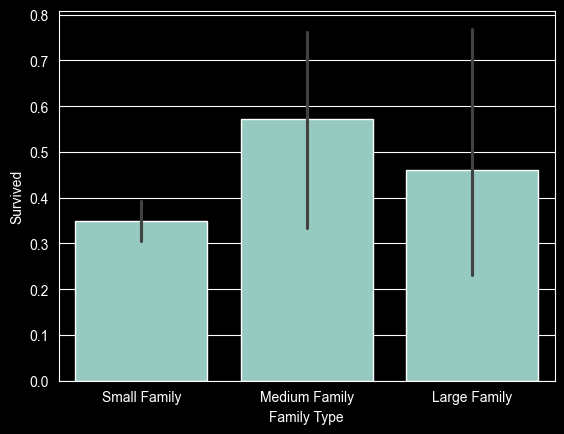

In [13]:
sns.barplot(data=df, x="Family Type", y="Survived")

In [17]:
pd.crosstab( df['Family Type'],df['Survived'], normalize=True)*100

Survived,0,1
Family Type,,
Large Family,1.674641,1.435407
Medium Family,2.153110,2.870813
Small Family,59.808612,32.057416


<Axes: xlabel='Survived', ylabel='Family Type'>

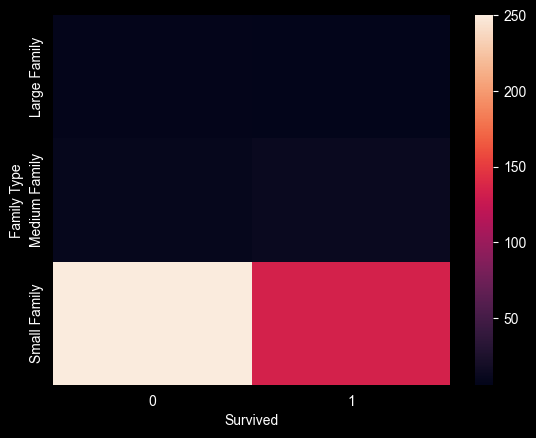

In [15]:
sns.heatmap(pd.crosstab( df['Family Type'],df['Survived']))

In [18]:
# Fare Category
df['Fare Category'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Mid', 'High','Very High'])

In [19]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family Size,Family Type,Fare Category
356,1248,1,1,"Brown, Mrs. John Murray (Caroline Lane Lamson)",female,59.0,2,0,11769,51.4792,S,3,Small Family,Very High
335,1227,0,1,"Maguire, Mr. John Edward",male,30.0,0,0,110469,26.0000,S,1,Small Family,High
367,1259,1,3,"Riihivouri, Miss. Susanna Juhantytar Sanni""""",female,22.0,0,0,3101295,39.6875,S,1,Small Family,Very High
347,1239,1,3,"Whabee, Mrs. George Joseph (Shawneene Abi-Saab)",female,38.0,0,0,2688,7.2292,C,1,Small Family,Low
230,1122,0,2,"Sweet, Mr. George Frederick",male,14.0,0,0,220845,65.0000,S,1,Small Family,Very High
199,1091,1,3,"Rasmussen, Mrs. (Lena Jacobsen Solvang)",female,27.0,0,0,65305,8.1125,S,1,Small Family,Mid
394,1286,0,3,"Kink-Heilmann, Mr. Anton",male,29.0,3,1,315153,22.0250,S,5,Medium Family,High
31,923,0,2,"Jefferys, Mr. Clifford Thomas",male,24.0,2,0,C.A. 31029,31.5000,S,3,Small Family,High
387,1279,0,2,"Ashby, Mr. John",male,57.0,0,0,244346,13.0000,S,1,Small Family,Mid
238,1130,1,2,"Hiltunen, Miss. Marta",female,18.0,1,1,250650,13.0000,S,3,Small Family,Mid
